# 03 — Baseline Models
**ZivaBasa MVP (Kaggle-Data Phase)**

Trains classical ML baselines — Logistic/Linear Regression, Decision Tree, Random Forest,
Gradient Boosting — **one set per task head** (Employment, Skills, Productivity), using the
processed features from `02_feature_engineering.ipynb`.

**Purpose:** these are the empirical bar the multi-task neural network (notebook 04) has to
clear. If the deep model doesn't beat these, that's a real finding to report, not something to
bury.

- Employment → classification (`target_high_automation_risk`)
- Skills → classification (`target_attrition`)
- Productivity → regression (`target_ai_adoption`)

All runs are logged to MLflow so today's numbers are auditable later.


In [3]:
# --- Setup ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42


### A note on MLflow

MLflow logging here is **optional and defensive**: if `import mlflow` fails (a broken local
install is a common issue -- mlflow depends on `pkg_resources`, part of `setuptools`, which is
sometimes missing in newer Python/conda environments) or `mlflow.start_run()` throws for any
other reason, training and evaluation still run to completion. You just won't get the MLflow run
history.

If you hit `ModuleNotFoundError: No module named 'pkg_resources'`, run:
```bash
pip install setuptools
```
in the environment this notebook is using. If that doesn't fix it, pinning the exact version
from `requirements.txt` (`pip install mlflow==2.14.1`) is the more durable fix -- mlflow's import
chain has been fragile across recent Python versions.


In [4]:
try:
    import mlflow
    mlflow.set_tracking_uri("../mlruns")
    mlflow.set_experiment("zivabasa_mvp_baselines")
    MLFLOW_AVAILABLE = True
    print("MLflow available -- runs will be logged to ../mlruns")
except Exception as e:
    MLFLOW_AVAILABLE = False
    print(f"MLflow unavailable ({type(e).__name__}: {e}) -- continuing WITHOUT run logging.")
    print("See the note above for how to fix your mlflow install; training below is unaffected.")

import contextlib

def mlflow_run_ctx(run_name):
    """Returns a real mlflow run context if available, else a harmless no-op context."""
    if MLFLOW_AVAILABLE:
        return mlflow.start_run(run_name=run_name)
    return contextlib.nullcontext()

def mlflow_log_param(key, value):
    if MLFLOW_AVAILABLE:
        try:
            mlflow.log_param(key, value)
        except Exception as e:
            print(f"[mlflow] log_param failed, continuing without it: {e}")

def mlflow_log_metrics(metrics_dict):
    if MLFLOW_AVAILABLE:
        try:
            mlflow.log_metrics(metrics_dict)
        except Exception as e:
            print(f"[mlflow] log_metrics failed, continuing without it: {e}")

def mlflow_log_sklearn_model(model, artifact_path="model"):
    if MLFLOW_AVAILABLE:
        try:
            mlflow.sklearn.log_model(model, artifact_path=artifact_path)
        except Exception as e:
            print(f"[mlflow] log_model failed, continuing without it: {e}")


MLflow unavailable (ModuleNotFoundError: No module named 'pkg_resources') -- continuing WITHOUT run logging.
See the note above for how to fix your mlflow install; training below is unaffected.


## 1. Load Processed Features


In [5]:
def load_features(name):
    path = os.path.join(PROCESSED_DIR, f"{name}_features.parquet")
    if not os.path.exists(path):
        print(f"[MISSING] {path} — run 02_feature_engineering.ipynb first.")
        return None
    df = pd.read_parquet(path)
    print(f"[{name}] loaded {df.shape[0]:,} rows x {df.shape[1]} cols")
    return df

feat_employment = load_features("employment")
feat_skills = load_features("skills")
feat_productivity = load_features("productivity")


[employment] loaded 3,000 rows x 39 cols
[skills] loaded 1,470 rows x 20 cols
[productivity] loaded 15,000 rows x 11 cols


## 2. Task Configuration

One config block per task head: target column, task type, and which columns to drop from the
feature matrix (targets, ID-like columns, anything that would leak the label).


In [6]:
TASK_CONFIG = {
    "employment": {
        "df": feat_employment,
        "target": "target_high_automation_risk",
        "task_type": "classification",
        "drop_cols": ["target_high_automation_risk", "automation_risk_score", "automation_exposure_index", "exposure_x_skill_complexity"],
    },
    "skills": {
        "df": feat_skills,
        "target": "target_attrition",
        "task_type": "classification",
        "drop_cols": ["target_attrition"],
    },
    "productivity": {
        "df": feat_productivity,
        "target": "target_ai_adoption",
        "task_type": "regression",
        "drop_cols": ["target_ai_adoption", "ai_adoption_level", "ai_adoption_index"],
    },
}

for name, cfg in TASK_CONFIG.items():
    df = cfg["df"]
    if df is None:
        print(f"[{name}] no data loaded — skipping.")
        continue
    if cfg["target"] not in df.columns:
        print(f"[{name}] WARNING — target '{cfg['target']}' not found. Re-check notebook 02, Section 9.")
    else:
        print(f"[{name}] target OK: '{cfg['target']}' ({cfg['task_type']})")


[employment] target OK: 'target_high_automation_risk' (classification)
[skills] target OK: 'target_attrition' (classification)
[productivity] target OK: 'target_ai_adoption' (regression)


## 3. Train / Test Split

80/20 split per task head, stratified on the target for classification tasks. Each task head is
split independently since the datasets aren't the same population (see README, Section 7).


In [7]:
splits = {}

for name, cfg in TASK_CONFIG.items():
    df = cfg["df"]
    if df is None or cfg["target"] not in df.columns:
        continue

    drop_cols = [c for c in cfg["drop_cols"] if c in df.columns]
    X = df.drop(columns=drop_cols)
    X = X.select_dtypes(include=[np.number])  # safety net: drop any leftover non-numeric cols
    y = df[cfg["target"]]

    stratify = y if cfg["task_type"] == "classification" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify
    )
    splits[name] = {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test}
    print(f"[{name}] train={X_train.shape[0]:,} test={X_test.shape[0]:,} features={X_train.shape[1]}")


[employment] train=2,400 test=600 features=7
[skills] train=1,176 test=294 features=8
[productivity] train=12,000 test=3,000 features=1


## 4. Model Zoo

Same four model types per task head, swapped between classifier/regressor variants based on
`task_type`.


In [8]:
def get_models(task_type):
    if task_type == "classification":
        return {
            "logistic_regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            "decision_tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
            "random_forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
            "gradient_boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
        }
    else:
        return {
            "linear_regression": LinearRegression(),
            "decision_tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
            "random_forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
            "gradient_boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
        }


## 5. Evaluation Functions

Classification → Accuracy, Precision, Recall, F1, ROC-AUC.
Regression → RMSE, MAE, R².


In [9]:
def evaluate_classification(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
        except ValueError:
            metrics["roc_auc"] = np.nan
    return metrics

def evaluate_regression(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


## 6. Train + Evaluate + Log to MLflow

Trains every model in the zoo for every task head, evaluates on the held-out test set, and logs
params/metrics/model artifact to MLflow under one run per (task_head, model_name) combination.


In [10]:
results = []

for task_name, cfg in TASK_CONFIG.items():
    if task_name not in splits:
        print(f"[{task_name}] skipped — no split available.")
        continue

    X_train, X_test = splits[task_name]["X_train"], splits[task_name]["X_test"]
    y_train, y_test = splits[task_name]["y_train"], splits[task_name]["y_test"]
    task_type = cfg["task_type"]
    models = get_models(task_type)

    for model_name, model in models.items():
        run_name = f"{task_name}_{model_name}"
        with mlflow_run_ctx(run_name):
            mlflow_log_param("task_head", task_name)
            mlflow_log_param("model_type", model_name)
            mlflow_log_param("task_type", task_type)
            mlflow_log_param("n_features", X_train.shape[1])
            mlflow_log_param("n_train", X_train.shape[0])
            mlflow_log_param("n_test", X_test.shape[0])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            if task_type == "classification":
                y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
                metrics = evaluate_classification(y_test, y_pred, y_proba)
            else:
                metrics = evaluate_regression(y_test, y_pred)

            mlflow_log_metrics({k: v for k, v in metrics.items() if not np.isnan(v)})
            mlflow_log_sklearn_model(model, artifact_path="model")

            row = {"task_head": task_name, "model": model_name, **metrics}
            results.append(row)
            print(f"[{run_name}] done -> {metrics}")

results_df = pd.DataFrame(results)
results_df


[employment_logistic_regression] done -> {'accuracy': 0.75, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.47816296296296296}
[employment_decision_tree] done -> {'accuracy': 0.71, 'precision': 0.25, 'recall': 0.08, 'f1': 0.12121212121212122, 'roc_auc': 0.495162962962963}
[employment_random_forest] done -> {'accuracy': 0.75, 'precision': 0.5, 'recall': 0.006666666666666667, 'f1': 0.013157894736842105, 'roc_auc': 0.45786666666666664}
[employment_gradient_boosting] done -> {'accuracy': 0.7316666666666667, 'precision': 0.21052631578947367, 'recall': 0.02666666666666667, 'f1': 0.047337278106508875, 'roc_auc': 0.4885037037037038}
[skills_logistic_regression] done -> {'accuracy': 0.826530612244898, 'precision': 0.25, 'recall': 0.0425531914893617, 'f1': 0.07272727272727272, 'roc_auc': 0.6800758032560944}
[skills_decision_tree] done -> {'accuracy': 0.7721088435374149, 'precision': 0.16666666666666666, 'recall': 0.10638297872340426, 'f1': 0.12987012987012986, 'roc_auc': 0.5007752605736

,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,employment,logistic_regression,0.750000,0.000000,0.000000,0.000000,0.478163,NaN,NaN,NaN
1,employment,decision_tree,0.710000,0.250000,0.080000,0.121212,0.495163,NaN,NaN,NaN
2,employment,random_forest,0.750000,0.500000,0.006667,0.013158,0.457867,NaN,NaN,NaN
3,employment,gradient_boosting,0.731667,0.210526,0.026667,0.047337,0.488504,NaN,NaN,NaN
4,skills,logistic_regression,0.826531,0.250000,0.042553,0.072727,0.680076,NaN,NaN,NaN
5,skills,decision_tree,0.772109,0.166667,0.106383,0.129870,0.500775,NaN,NaN,NaN
6,skills,random_forest,0.823129,0.368421,0.148936,0.212121,0.646524,NaN,NaN,NaN
7,skills,gradient_boosting,0.795918,0.303030,0.212766,0.250000,0.598717,NaN,NaN,NaN
8,productivity,linear_regression,NaN,NaN,NaN,NaN,NaN,0.993797,0.863194,-0.001151
9,productivity,decision_tree,NaN,NaN,NaN,NaN,NaN,1.006364,0.869790,-0.026630


## 7. Results Comparison

Side-by-side comparison per task head, best model highlighted. This is the empirical baseline
table that goes straight into your evaluation report / thesis chapter.


In [11]:
for task_name in TASK_CONFIG:
    task_results = results_df[results_df["task_head"] == task_name]
    if task_results.empty:
        continue
    print(f"=== {task_name.upper()} ===")
    sort_col = "roc_auc" if "roc_auc" in task_results.columns and task_results["roc_auc"].notna().any() else \
               ("r2" if "r2" in task_results.columns else task_results.columns[-1])
    display(task_results.sort_values(sort_col, ascending=False).reset_index(drop=True))
    print()


=== EMPLOYMENT ===


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,employment,decision_tree,0.710000,0.250000,0.080000,0.121212,0.495163,NaN,NaN,NaN
1,employment,gradient_boosting,0.731667,0.210526,0.026667,0.047337,0.488504,NaN,NaN,NaN
2,employment,logistic_regression,0.750000,0.000000,0.000000,0.000000,0.478163,NaN,NaN,NaN
3,employment,random_forest,0.750000,0.500000,0.006667,0.013158,0.457867,NaN,NaN,NaN



=== SKILLS ===


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,skills,logistic_regression,0.826531,0.250000,0.042553,0.072727,0.680076,NaN,NaN,NaN
1,skills,random_forest,0.823129,0.368421,0.148936,0.212121,0.646524,NaN,NaN,NaN
2,skills,gradient_boosting,0.795918,0.303030,0.212766,0.250000,0.598717,NaN,NaN,NaN
3,skills,decision_tree,0.772109,0.166667,0.106383,0.129870,0.500775,NaN,NaN,NaN



=== PRODUCTIVITY ===


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,productivity,linear_regression,NaN,NaN,NaN,NaN,NaN,0.993797,0.863194,-0.001151
1,productivity,random_forest,NaN,NaN,NaN,NaN,NaN,0.997211,0.865452,-0.008041
2,productivity,gradient_boosting,NaN,NaN,NaN,NaN,NaN,0.998659,0.866095,-0.010970
3,productivity,decision_tree,NaN,NaN,NaN,NaN,NaN,1.006364,0.869790,-0.026630


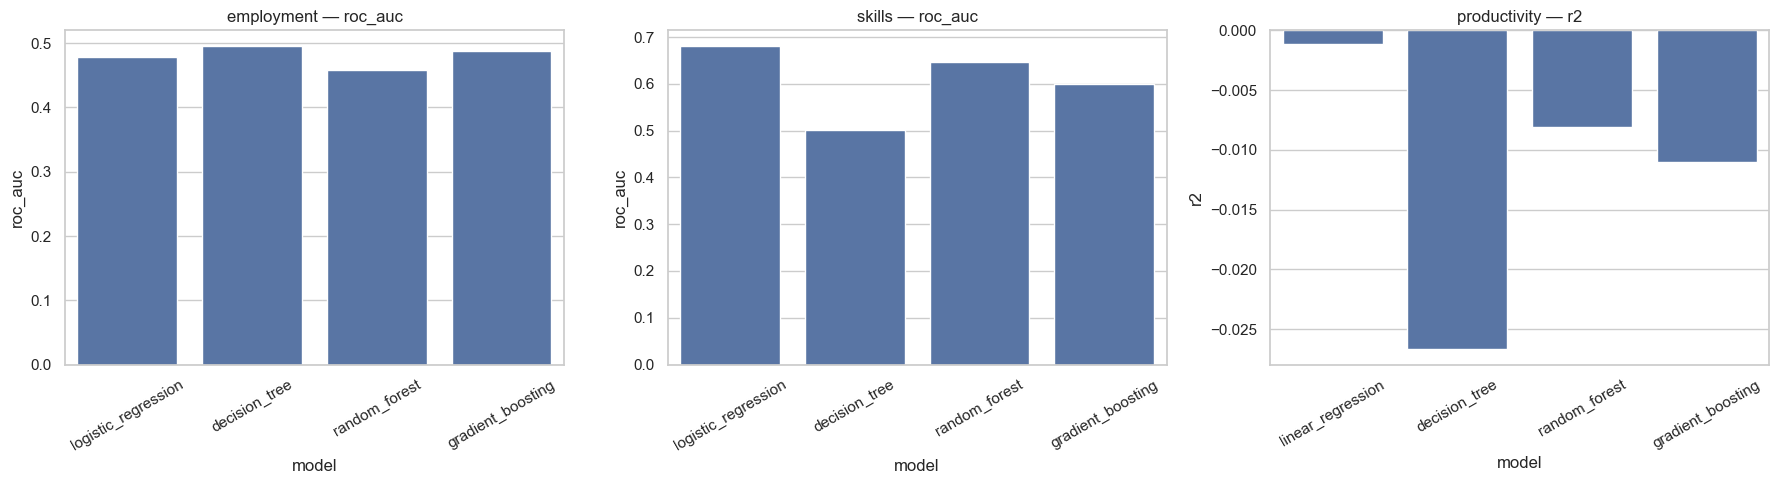

In [12]:
# Visual comparison
fig, axes = plt.subplots(1, len(TASK_CONFIG), figsize=(6 * len(TASK_CONFIG), 5))
axes = np.array(axes).reshape(-1)

for i, task_name in enumerate(TASK_CONFIG):
    task_results = results_df[results_df["task_head"] == task_name]
    if task_results.empty:
        axes[i].axis("off")
        continue
    metric_col = "roc_auc" if "roc_auc" in task_results.columns and task_results["roc_auc"].notna().any() else "r2"
    sns.barplot(data=task_results, x="model", y=metric_col, ax=axes[i])
    axes[i].set_title(f"{task_name} — {metric_col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 8. Feature Importance (Best Model per Task Head)

Tree-based feature importances give an early, cheap read on which engineered features matter —
useful context before SHAP runs on the neural network in notebook 05.


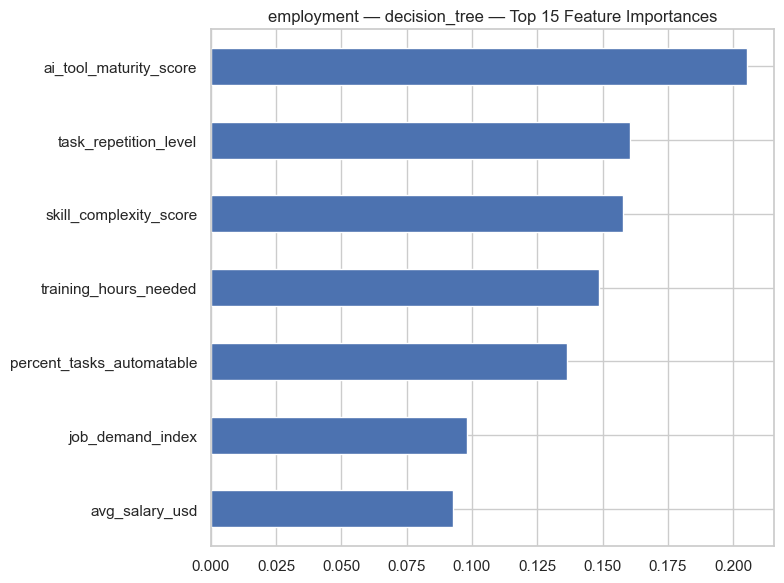

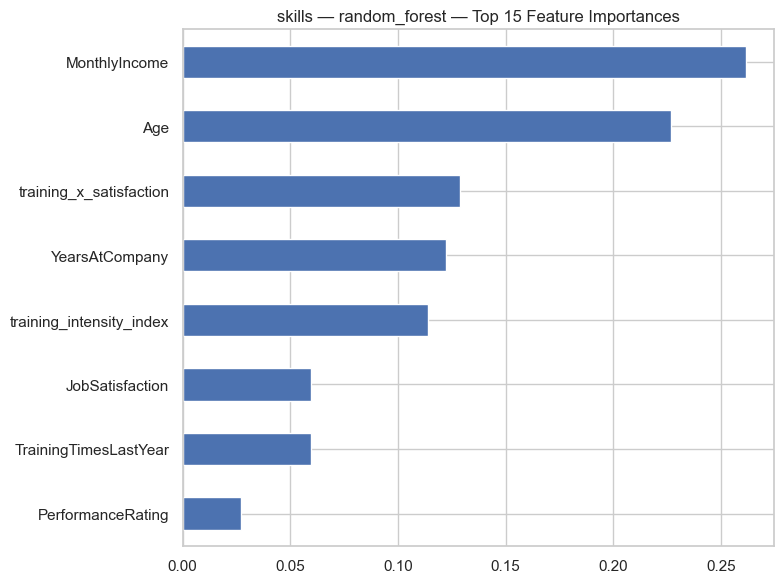

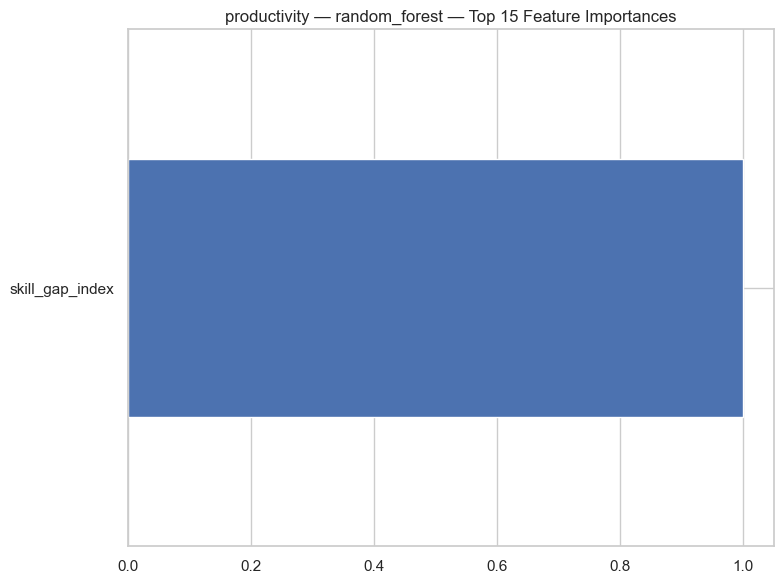

In [13]:
def plot_feature_importance(model, feature_names, task_name, model_name, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"[{task_name}/{model_name}] no feature_importances_ attribute, skipping.")
        return
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    importances.head(top_n).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"{task_name} — {model_name} — Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.show()

# Re-fit each task's best tree-based model on full training data for inspection
for task_name, cfg in TASK_CONFIG.items():
    if task_name not in splits:
        continue
    task_results = results_df[results_df["task_head"] == task_name]
    if task_results.empty:
        continue
    sort_col = "roc_auc" if "roc_auc" in task_results.columns and task_results["roc_auc"].notna().any() else "r2"
    tree_results = task_results[task_results["model"].isin(["random_forest", "gradient_boosting", "decision_tree"])]
    if tree_results.empty:
        continue
    best_model_name = tree_results.sort_values(sort_col, ascending=False).iloc[0]["model"]

    models = get_models(cfg["task_type"])
    best_model = models[best_model_name]
    best_model.fit(splits[task_name]["X_train"], splits[task_name]["y_train"])
    plot_feature_importance(best_model, splits[task_name]["X_train"].columns, task_name, best_model_name)


## 9. Save Results Table


In [14]:
results_path = os.path.join(MODELS_DIR, "baseline_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Baseline results saved -> {results_path}")

print("""
View the full MLflow run comparison with:
    mlflow ui --backend-store-uri ../mlruns
then open http://localhost:5000
""")


Baseline results saved -> ../models\baseline_results.csv

View the full MLflow run comparison with:
    mlflow ui --backend-store-uri ../mlruns
then open http://localhost:5000



## 10. Summary — Carry Forward to Notebook 04

- [ ] Best baseline metric noted per task head (this is the bar the multi-task NN must clear)
- [ ] Any task head with suspiciously perfect scores (accuracy/R² near 1.0) investigated for
      target leakage before moving on
- [ ] Class imbalance noted for classification tasks (check `y_train.value_counts()`) — may need
      `class_weight="balanced"` or resampling in the neural network
- [ ] Feature importances reviewed — do they make domain sense, or hint at a data quality issue?
